In [29]:
import pandas as pd
from IPython.display import Markdown, display


In [30]:
df = pd.read_csv("../output/sections_v2.csv")
df.head()


,section_id,doc_id,doc_type,year_th,year_ce,name_short,era,regime_type,parent_doc_id,chapter_number,chapter_title,sub_section_number,sub_section_title,section_number,section_role,target_chapter,target_section_no,change_mode,text
0,const_2475_s_1,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,NaN,NaN,1,content,NaN,NaN,content,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...
1,const_2475_s_2,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,NaN,NaN,2,content,NaN,NaN,content,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...
2,const_2475_s_3,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,1,พระมหากษัตริย์,NaN,NaN,3,content,NaN,NaN,content,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...
3,const_2475_s_4,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,1,พระมหากษัตริย์,NaN,NaN,4,content,NaN,NaN,content,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...
4,const_2475_s_5,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,1,พระมหากษัตริย์,NaN,NaN,5,content,NaN,NaN,content,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม


In [31]:
# Build hierarchy chart for each constitution: chapter -> subsection titles
hierarchy_rows = []

def clean_text(v):
    if pd.isna(v):
        return ""
    return str(v).strip()

def fmt_num(v):
    if pd.isna(v):
        return None
    try:
        f = float(v)
        return str(int(f)) if f.is_integer() else str(v)
    except Exception:
        return str(v).strip()

for (doc_id, name_short, year_th), g in df.groupby(["doc_id", "name_short", "year_th"], dropna=False, sort=True):
    hierarchy_rows.append(f"## {name_short} ({year_th}) — {doc_id}")

    chapter_order = (
        g[["chapter_number", "chapter_title"]]
        .drop_duplicates()
        .sort_values(by="chapter_number", na_position="last")
    )

    if chapter_order.empty:
        hierarchy_rows.append("- No chapter data")
        hierarchy_rows.append("")
        continue

    for _, ch in chapter_order.iterrows():
        ch_num = ch["chapter_number"]
        ch_title_raw = ch["chapter_title"]
        ch_title = clean_text(ch_title_raw)
        ch_num_text = fmt_num(ch_num)
        ch_label = f"Chapter {ch_num_text}" if ch_num_text else "Chapter (N/A)"
        hierarchy_rows.append(f"- {ch_label}: {ch_title}")

        if pd.isna(ch_title_raw):
            chapter_rows = g[g["chapter_title"].isna()]
        else:
            chapter_rows = g[g["chapter_title"] == ch_title_raw]

        sub_titles = chapter_rows[["sub_section_number", "sub_section_title"]].dropna(subset=["sub_section_title"])
        sub_titles = sub_titles[sub_titles["sub_section_title"].astype(str).str.strip() != ""]
        sub_titles = sub_titles.drop_duplicates().sort_values(by="sub_section_number", na_position="last")

        if sub_titles.empty:
            continue

        for _, sub in sub_titles.iterrows():
            sub_num = sub["sub_section_number"]
            sub_title = clean_text(sub["sub_section_title"])
            if pd.notna(sub_num):
                sub_num_text = fmt_num(sub_num)
                hierarchy_rows.append(f"  - Subsection {sub_num_text}: {sub_title}")
            else:
                hierarchy_rows.append(f"  - Subsection: {sub_title}")

    hierarchy_rows.append("")

hierarchy_markdown = "\n".join(hierarchy_rows)
display(Markdown(hierarchy_markdown))


## Constitution 2475 (2475) — const_2475
- Chapter 0: บททั่วไป
- Chapter 1: พระมหากษัตริย์
- Chapter 2: สิทธิและหน้าที่ของชนชาวสยาม
- Chapter 3: สภาผู้แทนราษฎร
- Chapter 4: คณะรัฐมนตรี
- Chapter 5: ศาล
- Chapter 6: บทสุดท้าย
- Chapter 7: การใช้รัฐธรรมนูญและบทฉะเพาะกาล

## Constitution 2482 (2482) — const_2482
- Chapter 0: 

## Constitution 2483 (2483) — const_2483
- Chapter 0: 

## Constitution 2485 (2485) — const_2485
- Chapter 0: 

## Constitution 2489 (2489) — const_2489
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 1: พระมหากษัตริย์
- Chapter 2: สิทธิและหน้าที่ของชนชาวไทย
- Chapter 3: อำนาจนิติบัญญัติ
  - Subsection 1: บททั่วไป
  - Subsection 2: พฤฆสภา
  - Subsection 3: สภาผู้แทน
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: บทที่ใช้แก่สภาทั้งสอง
- Chapter 4: อำนาจบริหาร
- Chapter 5: อำนาจตุลาการ
- Chapter 6: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 7: บทสุดท้าย

## Constitution 2490 (interim) (2490) — const_2490a
- Chapter 0: บททั่วไป
- Chapter 1: พระมหากษัตริย์
- Chapter 2: อภิรัฐมนตรี
- Chapter 3: สิทธิและหน้าที่ของชนชาวไทย
- Chapter 4: อำนาจนิติบัญญัติ
  - Subsection 1: บททั่วไป
  - Subsection 2: สภาผู้แทน
  - Subsection 3: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 4: การประชุมร่วมกันของรัฐสภา
- Chapter 5: อำนาจบริหาร
- Chapter 6: อำนาจตุลาการ
- Chapter 7: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 8: บทสุดท้าย

## Constitution 2490 (amended) (2490) — const_2490b
- Chapter 0: 

## Constitution 2491 (No.2) (2491) — const_2491a
- Chapter 0: 

## Constitution 2491 (No.3) (2491) — const_2491b
- Chapter 0: 

## Constitution 2492 (2492) — const_2492
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายแห่งรัฐ
- Chapter 6: อำนาจนิติบัญญัติ
  - Subsection 1: บททั่วไป
  - Subsection 2: วุฒิสภา
  - Subsection 3: สภาพแทน
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
- Chapter 7: อำนาจบริหาร
- Chapter 8: อำนาจตุลาการ
- Chapter 9: ตุลาการรัฐธรรมนูญ
- Chapter 10: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 11: บทสุดท้าย

## Constitution 2495 (2495) — const_2495
- Chapter -1: บทเฉพาะกาล
- Chapter 0: 
- Chapter 3: แนวนโยบายแห่งรัฐ
- Chapter 7: ตุลาการรัฐธรรมนูญ
- Chapter 8: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 9: บทสุดท้าย

## Constitution 2502 (2502) — const_2502
- Chapter 0: บททั่วไป

## Constitution 2511 (2511) — const_2511
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายแห่งรัฐ
- Chapter 6: อำนาจนิติบัญญัติ
  - Subsection 1: บททั่วไป
  - Subsection 2: วุฒิสภา
  - Subsection 3: สภาผู้แทน
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
- Chapter 7: อำนาจบริหาร
- Chapter 8: อำนาจตุลาการ
- Chapter 9: ตุลาการรัฐธรรมนูญ
- Chapter 10: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 11: บทสุดท้าย

## Constitution 2515 (2515) — const_2515
- Chapter 0: บททั่วไป

## Constitution 2517 (2517) — const_2517
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายแห่งรัฐ
- Chapter 6: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: วุฒิสภา
  - Subsection 3: สภาผู้แทนราษฎร
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
  - Subsection 6: ผู้ตรวจเงินแผ่นดินของรัฐสภา
  - Subsection 7: ข้าราชการฝ่ายรัฐสภา
- Chapter 7: คณะรัฐมนตรี
- Chapter 8: ศาล
- Chapter 9: การปกครองท้องถิ่น
- Chapter 10: ตุลาการรัฐธรรมนูญ
- Chapter 11: การแก้ไขเพิ่มเติมรัฐธรรมนูญ

## Constitution 2518 (2518) — const_2518
- Chapter 0: 

## Constitution 2519 (2519) — const_2519
- Chapter 0: บททั่วไป

## Constitution 2520 (2520) — const_2520
- Chapter 0: บททั่วไป

## Constitution 2521 (2521) — const_2521
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายแห่งรัฐ
- Chapter 6: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: วุฒิสภา
  - Subsection 3: สภาผู้แทนราษฎร
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
- Chapter 7: คณะรัฐมนตรี
- Chapter 8: ศาล
- Chapter 9: การปกครองส่วนท้องถิ่น
- Chapter 10: ตุลาการรัฐธรรมนูญ
- Chapter 11: การแก้ไขเพิ่มเติมรัฐธรรมนูญ

## Constitution 2528 (2528) — const_2528
- Chapter 0: 

## Constitution 2532 (2532) — const_2532
- Chapter 0: 

## Constitution 2534 (interim) (2534) — const_2534a
- Chapter 0: บททั่วไป

## Constitution 2534 (2534) — const_2534b
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายแห่งรัฐ
- Chapter 6: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: วุฒิสภา
  - Subsection 3: สภาผู้แทนราษฎร
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
- Chapter 7: คณะรัฐมนตรี
- Chapter 8: ศาล
- Chapter 9: การปกครองท้องถิ่น
- Chapter 10: ตุลาการรัฐธรรมนูญ
- Chapter 11: การแก้ไขเพิ่มเติมรัฐธรรมนูญ

## Constitution 2535 (No.1) (2535) — const_2535a
- Chapter 0: 

## Constitution 2535 (No.2) (2535) — const_2535b
- Chapter 0: 

## Constitution 2535 (No.3) (2535) — const_2535c
- Chapter 0: 

## Constitution 2535 (No.4) (2535) — const_2535d
- Chapter 0: 

## Constitution 2538 (2538) — const_2538
- Chapter 0: 

## Constitution 2539 (2539) — const_2539
- Chapter 0: 

## Constitution 2540 (2540) — const_2540
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายพื้นฐานแห่งรัฐ
- Chapter 6: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: สภาผู้แทนราษฎร
  - Subsection 3: วุฒิสภา
  - Subsection 4: คณะกรรมการการเลือกตั้ง
  - Subsection 5: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 6: การประชุมร่วมกันของรัฐสภา
  - Subsection 7: ผู้ตรวจการแผ่นดินของรัฐสภา
  - Subsection 8: คณะกรรมการสิทธิมนุษยชนแห่งชาติ
- Chapter 7: คณะรัฐมนตรี
- Chapter 8: ศาล
  - Subsection 1: บททั่วไป
  - Subsection 2: ศาลรัฐธรรมนูญ
  - Subsection 3: ศาลยุติธรรม
  - Subsection 4: ศาลปกครอง
  - Subsection 5: ศาลทหาร
- Chapter 9: การปกครองส่วนท้องถิ่น
- Chapter 10: การตรวจสอบการใช้อำนาจรัฐ
  - Subsection 1: การแสดงบัญชีรายการทรัพย์สินและหนี้สิน
  - Subsection 2: คณะกรรมการป้องกันและปราบปรามการทุจริตแห่งชาติ
  - Subsection 3: การถอดถอนจากตำแหน่ง
  - Subsection 4: การดำเนินคดีอาญากับผู้ดำรงตำแหน่งทางการเมือง
- Chapter 11: การตรวจเงินแผ่นดิน
- Chapter 12: การแก้ไขเพิ่มเติมรัฐธรรมนูญ

## Constitution 2548 (2548) — const_2548
- Chapter 0: 

## Constitution 2549 (interim) (2549) — const_2549
- Chapter 0: บททั่วไป

## Constitution 2550 (2550) — const_2550
- Chapter -1: บทเฉพาะกาล
- Chapter 0: บททั่วไป
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของชนชาวไทย
  - Subsection 1: บททั่วไป
  - Subsection 2: ความเสมอภาค
  - Subsection 3: สิทธิและเสรีภาพส่วนบุคคล
  - Subsection 4: สิทธิในกระบวนการยุติธรรม
  - Subsection 5: สิทธิในทรัพย์สิน
  - Subsection 6: สิทธิและเสรีภาพในการประกอบอาชีพ
  - Subsection 7: เสรีภาพในการแสดงความคิดเห็นของบุคคลและสื่อมวลชน
  - Subsection 8: สิทธิและเสรีภาพในการศึกษา
  - Subsection 9: สิทธิในการได้รับบริการสาธารณสุขและสวัสดิการจากรัฐ
  - Subsection 10: สิทธิในข้อมูลข่าวสารและการร้องเรียน
  - Subsection 11: เสรีภาพในการชุมนุมและการสมาคม
  - Subsection 12: สิทธิชุมชน
  - Subsection 13: สิทธิพิทักษ์รัฐธรรมนูญ
- Chapter 4: หน้าที่ของชนชาวไทย
- Chapter 5: แนวนโยบายพื้นฐานแห่งรัฐ
  - Subsection 1: บททั่วไป
  - Subsection 2: แนวนโยบายด้านความมั่นคงของรัฐ
  - Subsection 3: แนวนโยบายด้านการบริหารราชการแผ่นดิน
  - Subsection 4: แนวนโยบายด้านศาสนา สังคม การสาธารณสุข การศึกษา และวัฒนธรรม
  - Subsection 5: แนวนโยบายด้านกฎหมายและการยุติธรรม
  - Subsection 6: แนวนโยบายด้านการต่างประเทศ
  - Subsection 7: แนวนโยบายด้านเศรษฐกิจ
  - Subsection 8: แนวนโยบายด้านที่ดิน ทรัพยากรธรรมชาติ และสิ่งแวดล้อม
  - Subsection 9: แนวนโยบายด้านวิทยาศาสตร์ ทรัพย์สินทางปัญญา และพลังงาน
  - Subsection 10: แนวนโยบายด้านการมีส่วนร่วมของประชาชน
- Chapter 6: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: สภาผู้แทนราษฎร
  - Subsection 3: วุฒิสภา
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
  - Subsection 6: การตราพระราชบัญญัติประกอบรัฐธรรมนูญ
  - Subsection 7: การตราพระราชบัญญัติ
  - Subsection 8: การควบคุมการตรากฎหมายที่ขัดหรือแย้งต่อรัฐธรรมนูญ
  - Subsection 9: การควบคุมการบริหารราชการแผ่นดิน
- Chapter 7: การมีส่วนร่วมทางการเมืองโดยตรงของประชาชน
- Chapter 8: การเงิน การคลัง และงบประมาณ
- Chapter 9: คณะรัฐมนตรี
- Chapter 10: ศาล
  - Subsection 1: บททั่วไป
  - Subsection 2: ศาลรัฐธรรมนูญ
  - Subsection 3: ศาลยุติธรรม
  - Subsection 4: ศาลปกครอง
  - Subsection 5: ศาลทหาร
- Chapter 11: องค์กรตามรัฐธรรมนูญ
  - Subsection 1: องค์กรอิสระตามรัฐธรรมนูญ
  - Subsection 2: องค์กรอื่นตามรัฐธรรมนูญ
- Chapter 12: การตรวจสอบการใช้อํานาจรัฐ
  - Subsection 1: การตรวจสอบทรัพย์สิน
  - Subsection 2: การกระทําที่เป็นการขัดกันแห่งผลประโยชน์
  - Subsection 3: การถอดถอนจากตำแหน่ง
  - Subsection 4: การดําเนินคดีอาญาผู้ดํารงตําแหน่งทางการเมือง
- Chapter 13: จริยธรรมของผู้ดํารงตําแหน่งทางการเมืองและเจ้าหน้าที่ของรัฐ
- Chapter 14: การปกครองส่วนท้องถิ่น
- Chapter 15: การแก้ไขเพิ่มเติมรัฐธรรมนูญ

## Constitution 2554 (No.1) (2554) — const_2554a
- Chapter 0: 

## Constitution 2554 (No.2) (2554) — const_2554b
- Chapter 0: 

## Constitution 2557 (interim) (2557) — const_2557
- Chapter 0: บททั่วไป

## Constitution 2560 (2560) — const_2560
- Chapter -1: บทเฉพาะกาล
- Chapter 2: พระมหากษัตริย์
- Chapter 3: สิทธิและเสรีภาพของปวงชนชาวไทย
- Chapter 4: หน้าที่ของปวงชนชาวไทย
- Chapter 5: หน้าที่ของรัฐ
- Chapter 6: แนวนโยบายแห่งรัฐ
- Chapter 7: รัฐสภา
  - Subsection 1: บททั่วไป
  - Subsection 2: สภาผู้แทนราษฎร
  - Subsection 3: วุฒิสภา
  - Subsection 4: บทที่ใช้แก่สภาทั้งสอง
  - Subsection 5: การประชุมร่วมกันของรัฐสภา
- Chapter 8: คณะรัฐมนตรี
- Chapter 9: การขัดกันแห่งผลประโยชน์
- Chapter 10: ศาล
  - Subsection 1: บททั่วไป
  - Subsection 2: ศาลยุติธรรม
  - Subsection 3: ศาลปกครอง
  - Subsection 4: ศาลทหาร
- Chapter 11: ศาลรัฐธรรมนูญ
- Chapter 12: องค์กรอิสระ
  - Subsection 1: บททั่วไป
  - Subsection 2: คณะกรรมการการเลือกตั้ง
  - Subsection 3: ผู้ตรวจการแผ่นดิน
  - Subsection 4: คณะกรรมการป้องกันและปราบปรามการทุจริตแห่งชาติ
  - Subsection 5: คณะกรรมการตรวจเงินแผ่นดิน
  - Subsection 6: คณะกรรมการสิทธิมนุษยชนแห่งชาติ
- Chapter 13: องค์กรอัยการ
- Chapter 14: การปกครองส่วนท้องถิ่น
- Chapter 15: การแก้ไขเพิ่มเติมรัฐธรรมนูญ
- Chapter 16: การปฏิรูปประเทศ

## Constitution 2564 (2564) — const_2564
- Chapter 0: 


In [32]:
# Optional: save hierarchy text for reuse
with open("../output/constitution_hierarchy_chart.md", "w", encoding="utf-8") as f:
    f.write(hierarchy_markdown)

print("Saved to ../output/constitution_hierarchy_chart.md")


Saved to ../output/constitution_hierarchy_chart.md


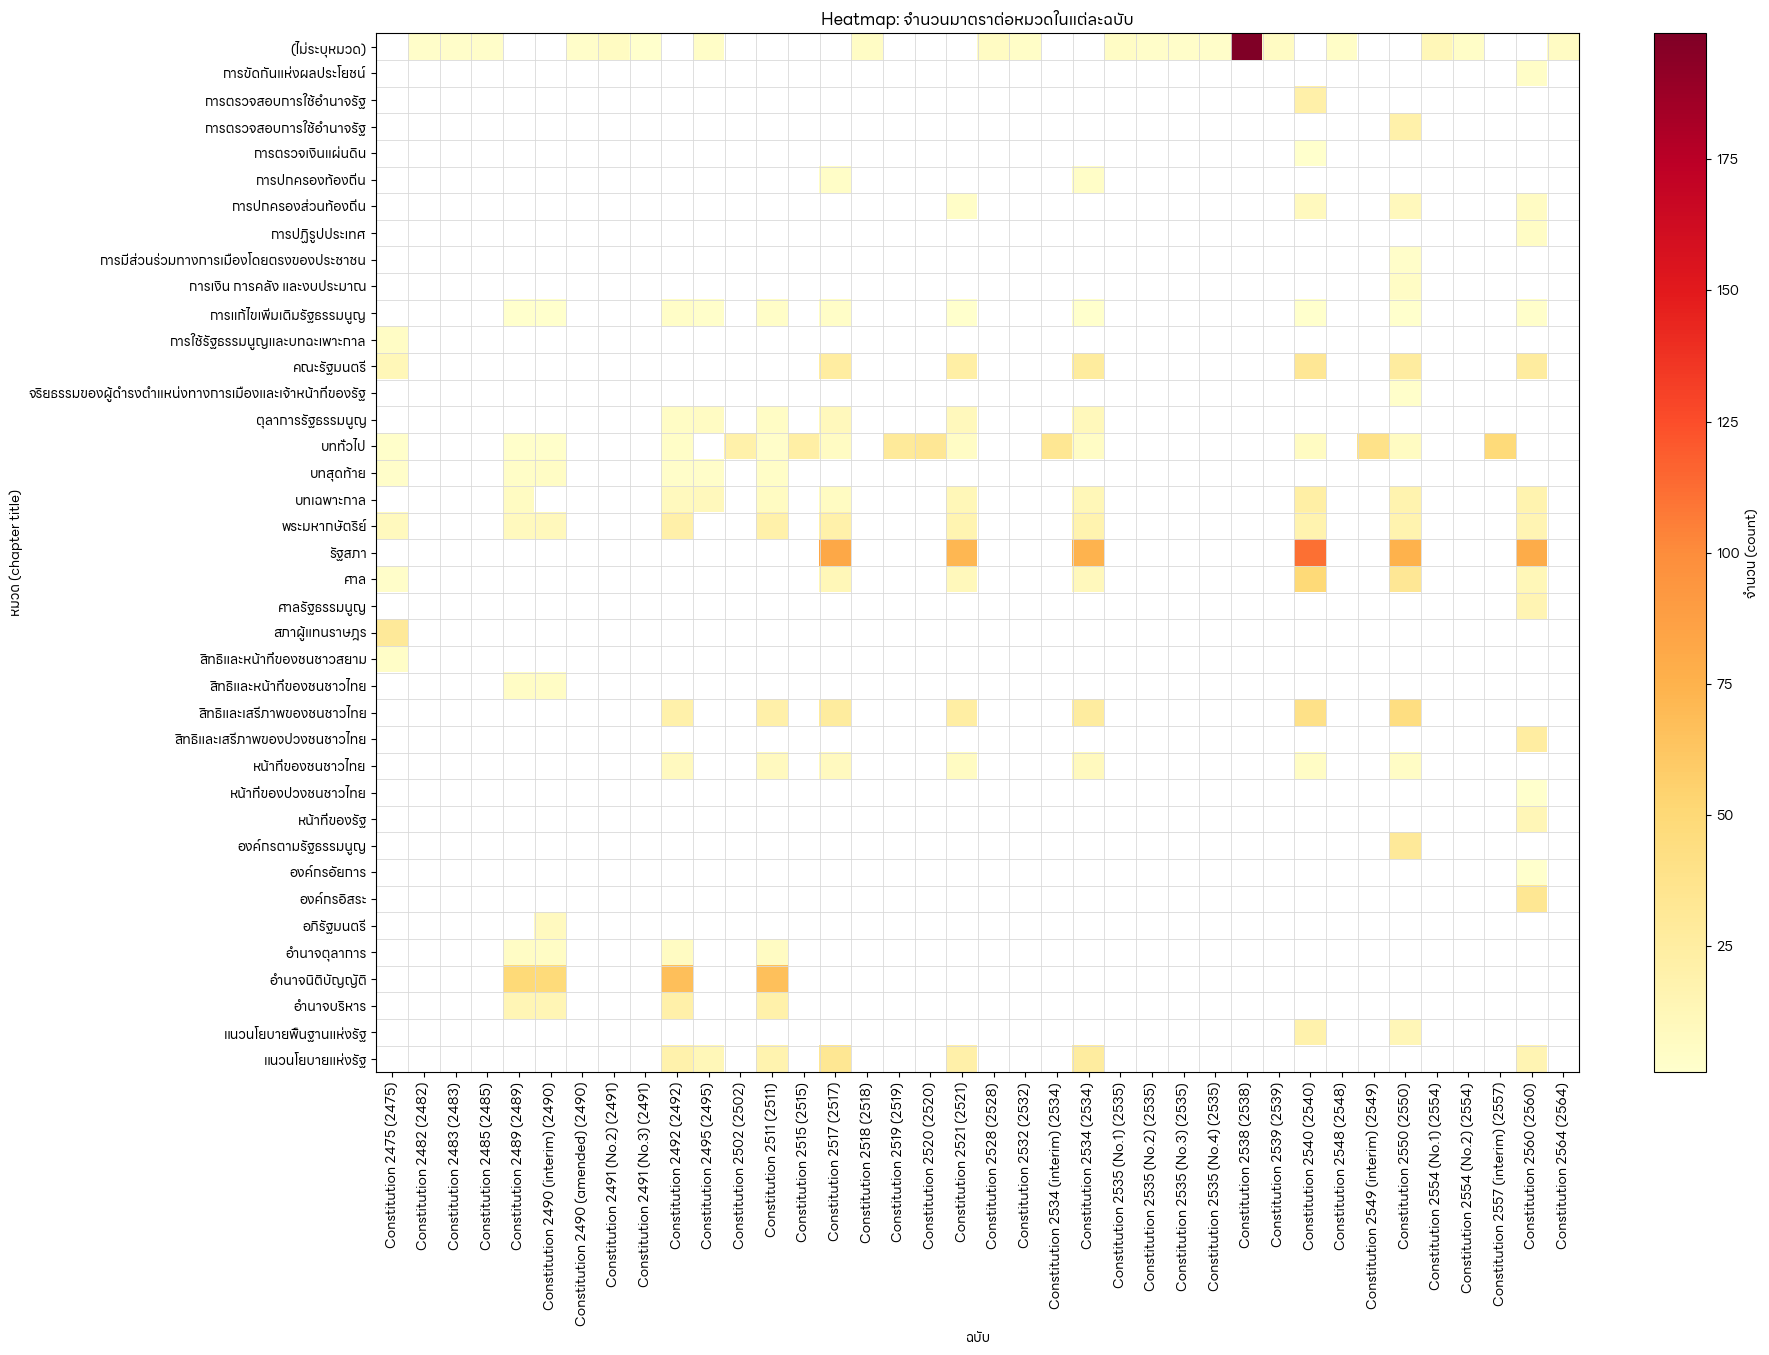

In [34]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Thai font setup
font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

# Build labels for x-axis (ฉบับ)
df_plot = df.copy()
df_plot['constitution_label'] = df_plot['name_short'].fillna(df_plot['doc_id']) + ' (' + df_plot['year_th'].astype(str) + ')'
df_plot['chapter_title_clean'] = df_plot['chapter_title'].fillna('(ไม่ระบุหมวด)').astype(str).str.strip()
df_plot.loc[df_plot['chapter_title_clean'] == '', 'chapter_title_clean'] = '(ไม่ระบุหมวด)'

# Count unique section numbers by (constitution, chapter) for duplicate safety
heat = (
    df_plot.groupby(['chapter_title_clean', 'constitution_label'])['section_number']
    .nunique(dropna=True)
    .unstack(fill_value=0)
)

# Keep constitutions in chronological order
constitution_order = (
    df_plot[['constitution_label', 'year_th', 'doc_id']]
    .drop_duplicates()
    .sort_values(['year_th', 'doc_id'])['constitution_label']
    .tolist()
)
heat = heat.reindex(columns=constitution_order)

# Plot heatmap
fig, ax = plt.subplots(figsize=(max(12, len(heat.columns) * 0.5), max(8, len(heat.index) * 0.35)))
heat_values = heat.values.astype(float)
mask_zero = heat_values == 0
heat_masked = np.ma.masked_where(mask_zero, heat_values)
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='white')
im = ax.imshow(heat_masked, aspect='auto', cmap=cmap)

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_xlabel('ฉบับ')
ax.set_ylabel('หมวด (chapter title)')
ax.set_title('Heatmap: จำนวนมาตราต่อหมวดในแต่ละฉบับ')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('จำนวน (count)')


# Cell grid
ax.set_xticks([x - 0.5 for x in range(1, len(heat.columns))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(heat.index))], minor=True)
ax.grid(which='minor', color='#D9D9D9', linestyle='-', linewidth=0.6)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.show()


In [38]:
# Full chapter-title list (A-Z) without notebook truncation
chapter_titles_sorted = sorted(
    t for t in df['chapter_title'].fillna('').astype(str).str.strip().unique() if t
)

print('\n'.join(f"{i}. {title}" for i, title in enumerate(chapter_titles_sorted, 1)))


1. การขัดกันแห่งผลประโยชน์
2. การตรวจสอบการใช้อำนาจรัฐ
3. การตรวจสอบการใช้อํานาจรัฐ
4. การตรวจเงินแผ่นดิน
5. การปกครองท้องถิ่น
6. การปกครองส่วนท้องถิ่น
7. การปฏิรูปประเทศ
8. การมีส่วนร่วมทางการเมืองโดยตรงของประชาชน
9. การเงิน การคลัง และงบประมาณ
10. การแก้ไขเพิ่มเติมรัฐธรรมนูญ
11. การใช้รัฐธรรมนูญและบทฉะเพาะกาล
12. คณะรัฐมนตรี
13. จริยธรรมของผู้ดํารงตําแหน่งทางการเมืองและเจ้าหน้าที่ของรัฐ
14. ตุลาการรัฐธรรมนูญ
15. บททั่วไป
16. บทสุดท้าย
17. บทเฉพาะกาล
18. พระมหากษัตริย์
19. รัฐสภา
20. ศาล
21. ศาลรัฐธรรมนูญ
22. สภาผู้แทนราษฎร
23. สิทธิและหน้าที่ของชนชาวสยาม
24. สิทธิและหน้าที่ของชนชาวไทย
25. สิทธิและเสรีภาพของชนชาวไทย
26. สิทธิและเสรีภาพของปวงชนชาวไทย
27. หน้าที่ของชนชาวไทย
28. หน้าที่ของปวงชนชาวไทย
29. หน้าที่ของรัฐ
30. องค์กรตามรัฐธรรมนูญ
31. องค์กรอัยการ
32. องค์กรอิสระ
33. อภิรัฐมนตรี
34. อำนาจตุลาการ
35. อำนาจนิติบัญญัติ
36. อำนาจบริหาร
37. แนวนโยบายพื้นฐานแห่งรัฐ
38. แนวนโยบายแห่งรัฐ


In [40]:
# Full chapter list (A-Z) with subsection titles, no truncation
work = df[['chapter_title', 'sub_section_title']].copy()
work['chapter_title'] = work['chapter_title'].fillna('').astype(str).str.strip()
work['sub_section_title'] = work['sub_section_title'].fillna('').astype(str).str.strip()
work = work[work['chapter_title'] != '']

lines = []
for i, chapter in enumerate(sorted(work['chapter_title'].unique()), 1):
    lines.append(f"{i}. {chapter}")
    subs = sorted([s for s in work.loc[work['chapter_title'] == chapter, 'sub_section_title'].unique() if s])
    for j, sub in enumerate(subs, 1):
        lines.append(f"   {i}.{j} {sub}")

print('\n'.join(lines))


1. การขัดกันแห่งผลประโยชน์
2. การตรวจสอบการใช้อำนาจรัฐ
   2.1 การดำเนินคดีอาญากับผู้ดำรงตำแหน่งทางการเมือง
   2.2 การถอดถอนจากตำแหน่ง
   2.3 การแสดงบัญชีรายการทรัพย์สินและหนี้สิน
   2.4 คณะกรรมการป้องกันและปราบปรามการทุจริตแห่งชาติ
3. การตรวจสอบการใช้อํานาจรัฐ
   3.1 การกระทําที่เป็นการขัดกันแห่งผลประโยชน์
   3.2 การดําเนินคดีอาญาผู้ดํารงตําแหน่งทางการเมือง
   3.3 การตรวจสอบทรัพย์สิน
   3.4 การถอดถอนจากตำแหน่ง
4. การตรวจเงินแผ่นดิน
5. การปกครองท้องถิ่น
6. การปกครองส่วนท้องถิ่น
7. การปฏิรูปประเทศ
8. การมีส่วนร่วมทางการเมืองโดยตรงของประชาชน
9. การเงิน การคลัง และงบประมาณ
10. การแก้ไขเพิ่มเติมรัฐธรรมนูญ
11. การใช้รัฐธรรมนูญและบทฉะเพาะกาล
12. คณะรัฐมนตรี
13. จริยธรรมของผู้ดํารงตําแหน่งทางการเมืองและเจ้าหน้าที่ของรัฐ
14. ตุลาการรัฐธรรมนูญ
15. บททั่วไป
16. บทสุดท้าย
17. บทเฉพาะกาล
18. พระมหากษัตริย์
19. รัฐสภา
   19.1 การควบคุมการตรากฎหมายที่ขัดหรือแย้งต่อรัฐธรรมนูญ
   19.2 การควบคุมการบริหารราชการแผ่นดิน
   19.3 การตราพระราชบัญญัติ
   19.4 การตราพระราชบัญญัติประกอบรัฐธรรมนูญ
   19.5 การประช

จัดหมวดหมู่

1. หมวดทั่วไปและโครงสร้างพื้นฐาน
- บททั่วไป
- บทสุดท้าย
- บทเฉพาะกาล / การใช้รัฐธรรมนูญและบทเฉพาะกาล
- การแก้ไขเพิ่มเติมรัฐธรรมนูญ

2. สถาบันพระมหากษัตริย์
- พระมหากษัตริย์

3. สิทธิ เสรีภาพ และหน้าที่ของประชาชน
- สิทธิและเสรีภาพของชนชาวไทย / ปวงชนชาวไทย   
- สิทธิและหน้าที่ของชนชาวไทย / ชนชาวสยาม
- หน้าที่ของชนชาวไทย / ปวงชนชาวไทย
- สิทธิและเสรีภาพ (หมวดย่อย 25.x ทั้งหมด)
- หน้าที่ของรัฐ

4. แนวนโยบายแห่งรัฐ
- แนวนโยบายพื้นฐานแห่งรัฐ
- แนวนโยบายแห่งรัฐ
- (รวมหมวดย่อย 37.x ทั้งหมด)

5. อำนาจอธิปไตย (3 ฝ่าย)
5.1 อำนาจนิติบัญญัติ
- รัฐสภา
- สภาผู้แทนราษฎร
- วุฒิสภา
- การตรากฎหมาย (19.x และ 35.x)
- การประชุมร่วม
5.2 อำนาจบริหาร
- คณะรัฐมนตรี
- อำนาจบริหาร
5.3 อำนาจตุลาการ
- ศาล
- ศาลยุติธรรม / ปกครอง / ทหาร
- ศาลรัฐธรรมนูญ
- อำนาจตุลาการ

6. องค์กรตามรัฐธรรมนูญและองค์กรอิสระ
- องค์กรตามรัฐธรรมนูญ
- องค์กรอิสระ
- องค์กรอัยการ
- คณะกรรมการต่าง ๆ เช่น
- กกต.
- ป.ป.ช.
- ผู้ตรวจการแผ่นดิน
- สตง.
- กสม.

7. การตรวจสอบการใช้อำนาจรัฐและการป้องกันทุจริต (รวมกลุ่มหัวข้อซ้ำ 2 และ 3)
- การตรวจสอบการใช้อำนาจรัฐ
- การขัดกันแห่งผลประโยชน์
- การตรวจสอบทรัพย์สิน
- การถอดถอน
- การดำเนินคดีนักการเมือง
- การแสดงบัญชีทรัพย์สิน
- ป.ป.ช.

8. การคลังและการตรวจเงินแผ่นดิน
- การเงิน การคลัง และงบประมาณ
- การตรวจเงินแผ่นดิน

9. การปกครองส่วนท้องถิ่น
- การปกครองท้องถิ่น
- การปกครองส่วนท้องถิ่น

10. การมีส่วนร่วมทางการเมือง
- การมีส่วนร่วมทางการเมืองโดยตรงของประชาชน

11. การปฏิรูปประเทศ
- การปฏิรูปประเทศ

12. จริยธรรมและมาตรฐานทางการเมือง
- จริยธรรมของผู้ดำรงตำแหน่งทางการเมืองและเจ้าหน้าที่ของรัฐ

13.พรรคการเมืองและการเลือกตั้ง

14. อื่น ๆ